# Notebook 01: Physics RLVR — SFT Warmup

Supervised fine-tuning (SFT) on 70 MMLU-Pro examples to teach `Qwen3-4B-Base` the
XML output schema. This is **format-only** training — we are not injecting physics
knowledge. The base model already has that. We are only teaching it to structure its
responses as:

```
<START_WORKING_OUT>
...step-by-step reasoning...
</END_WORKING_OUT>
<SOLUTION>
single letter answer (A–J)
</SOLUTION>
```

**Input**: `physics_rlvr/data/sft_train.jsonl` — 70 rows, all categories,
fields: `question`, `options`, `answer`, `cot_content`

**Output**: `physics_rlvr/models/qwen3-4b-physics-sft/` — merged 16-bit weights
for direct loading in GRPO (Notebook 02) and vLLM evaluation (Notebook 03)

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/grpo-verified-reasoner
!ls

Mounted at /content/drive
/content/drive/MyDrive/grpo-verified-reasoner
data			      models	    README.md			 wandb
grpo_trainer_lora_model       notebooks     src
huggingface_tokenizers_cache  outputs	    unsloth_compiled_cache
LICENSE			      physics_rlvr  _unsloth_sentencepiece_temp


In [2]:
!nvidia-smi

Thu Feb 26 05:47:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   47C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2: Install Dependencies and Import Libraries

In [3]:
!pip install -q unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import os
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported
from unsloth.chat_templates import get_chat_template
from unsloth.chat_templates import train_on_responses_only

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [5]:
# Prevent unsloth from spinning up vLLM during SFT — we don't need it here
os.environ["UNSLOTH_VLLM_STANDBY"] = "1"

## Step 3: Verify GPU

In [6]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("bfloat16 supported:", is_bfloat16_supported())

Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4
bfloat16 supported: True


## Step 4: Load Base Model with LoRA

We load `Qwen3-4B-Base` in full 16-bit precision and attach LoRA adapters. Key configuration choices:

- **`r=32`, `lora_alpha=64`**: Rank-32 LoRA with alpha=2×r is the standard initialization for task-specific fine-tuning. Higher rank than typical (r=8/16) because we want sufficient capacity to learn the XML output schema reliably.
- **Target modules**: All attention projections (`q/k/v/o`) plus all MLP projections (`gate/up/down`). Targeting the full transformer (not just attention) gives better format learning, which is our primary objective.
- **`load_in_4bit=False`**: Full 16-bit precision for training stability. 4-bit quantization is for inference only.
- **`fast_inference=False`**: Disables vLLM — not needed for SFT, only for GRPO rollout generation.

In [7]:
MODEL_NAME    = "unsloth/Qwen3-4B-Base"
MAX_SEQ_LENGTH = 3072
LORA_RANK     = 32

In [8]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = False,   # 16-bit LoRA: more stable for training
    fast_inference = False,   # training mode, not serving
)

==((====))==  Unsloth 2026.2.1: Fast Qwen3 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.08G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

In [ ]:
# Attach LoRA adapters to the base model
# r=32, alpha=64: standard alpha=2*r scaling; rank-32 gives enough capacity for schema learning
# target_modules: all attention + MLP projections — full transformer coverage for format training
# use_gradient_checkpointing="unsloth": Unsloth's memory-efficient checkpointing (reduces VRAM ~30%)
model = FastLanguageModel.get_peft_model(
    model,
    r              = LORA_RANK,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha               = LORA_RANK * 2,   # alpha = 64
    use_gradient_checkpointing = "unsloth",
    random_state             = 42,
)

In [ ]:
# Apply ChatML template — Qwen3 uses ChatML natively
# map_eos_token=True: maps <|im_end|> → EOS so the model learns to stop generating at turn boundaries
tokenizer = get_chat_template(
    tokenizer,
    chat_template  = "chatml",
    map_eos_token  = True,
)

## Step 5: Load SFT Dataset

In [11]:
DATA_PATH = "physics_rlvr/data/sft_train.jsonl"
dataset = load_dataset("json", data_files=DATA_PATH, split="train")

print(f"Loaded {len(dataset)} SFT samples.")
print("Columns:", dataset.column_names)

assert len(dataset) >= 50, f"Too few SFT samples: {len(dataset)}"
assert "question"    in dataset.column_names
assert "options"     in dataset.column_names
assert "answer"      in dataset.column_names
assert "cot_content" in dataset.column_names

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 70 SFT samples.
Columns: ['question', 'options', 'answer', 'cot_content']


In [12]:
# Inspect one example to verify the raw fields
ex = dataset[0]
print("question:   ", ex["question"][:100])
print("options:    ", ex["options"][:3], "...")
print("answer:     ", ex["answer"])
print("cot_content:", ex["cot_content"][:])

question:    The symmetric group $S_n$ has $
\factorial{n}$ elements, hence it is not true that $S_{10}$ has 10 e
options:     ['0', '30', '3'] ...
answer:      A
cot_content: A: Let's think step by step. A characteristic of a ring is R is $n$ if the statement $ka = 0$ for all $a\in 2Z$ implies that $k$ is a multiple of $n$. Assume that $ka = 0$ for all $a\in 2Z$ for some $k$. In particular $2k = 0$. Hence $k=0$ and $n=0$. The answer is (A).


## Step 6: Build Chat-Formatted Training Text

Each raw example has `question`, `options` (list), `answer` (letter), and `cot_content`
(pre-written CoT trace). We map these to ChatML format:

- **user turn**: formatted question + options (A. option1  B. option2 ...)
- **assistant turn**: `<START_WORKING_OUT>cot_content</END_WORKING_OUT><SOLUTION>answer</SOLUTION>`

In [13]:
SYSTEM_PROMPT = """You are a physics reasoning engine.

You must output your response in the following exact format:

<START_WORKING_OUT>
Step-by-step reasoning to solve the physics problem.
</END_WORKING_OUT>
<SOLUTION>
Single letter answer only (A, B, C, D, E, F, G, H, I, or J).
</SOLUTION>

Do not output anything outside these tags."""

In [14]:
def format_example(example):
    """
    Convert an MMLU-Pro example into a ChatML-formatted training string.

    user turn  : question + options formatted as 'A. option_text\nB. option_text ...'
    asst turn  : <START_WORKING_OUT>cot_content</END_WORKING_OUT><SOLUTION>answer</SOLUTION>
    """
    question      = example["question"]
    options       = example["options"]       # list of strings
    cot           = example["cot_content"]   # starts with "A: Let's think step by step..."
    answer_letter = example["answer"]        # e.g. "E"

    # Format options as A. ... B. ... regardless of how many options exist
    option_str = "\n".join(
        f"{chr(65 + i)}. {opt}" for i, opt in enumerate(options)
    )
    user_content = f"{question}\n\nOptions:\n{option_str}"

    assistant_content = (
        f"<START_WORKING_OUT>\n{cot}\n</END_WORKING_OUT>\n"
        f"<SOLUTION>\n{answer_letter}\n</SOLUTION>"
    )

    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": user_content},
        {"role": "assistant", "content": assistant_content},
    ]

    # tokenize=False: return raw ChatML string, not token ids
    # add_generation_prompt=False: do not append the assistant generation prefix
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

In [15]:
# Apply to all 70 examples
dataset = dataset.map(format_example, remove_columns=dataset.column_names)

print("Sample formatted text (truncated to 800 chars):\n")
print(dataset[0]["text"][:])

Map:   0%|          | 0/70 [00:00<?, ? examples/s]

Sample formatted text (truncated to 800 chars):

<|im_start|>system
You are a physics reasoning engine.

You must output your response in the following exact format:

<START_WORKING_OUT>
Step-by-step reasoning to solve the physics problem.
</END_WORKING_OUT>
<SOLUTION>
Single letter answer only (A, B, C, D, E, F, G, H, I, or J).
</SOLUTION>

Do not output anything outside these tags.<|im_end|>
<|im_start|>user
The symmetric group $S_n$ has $
\factorial{n}$ elements, hence it is not true that $S_{10}$ has 10 elements.
Find the characteristic of the ring 2Z.

Options:
A. 0
B. 30
C. 3
D. 10
E. 12
F. 50
G. 2
H. 100
I. 20
J. 5<|im_end|>
<|im_start|>assistant
<START_WORKING_OUT>
A: Let's think step by step. A characteristic of a ring is R is $n$ if the statement $ka = 0$ for all $a\in 2Z$ implies that $k$ is a multiple of $n$. Assume that $ka = 0$ for all $a\in 2Z$ for some $k$. In particular $2k = 0$. Hence $k=0$ and $n=0$. The answer is (A).
</END_WORKING_OUT>
<SOLUTION>
A
</SOLUTION><|im_

In [16]:
dataset

Dataset({
    features: ['text'],
    num_rows: 70
})

## Step 7: Masking Unit Test

By default, SFTTrainer computes loss on **all** tokens — including the system prompt
and the user question. We only want loss on the **assistant reply** (the XML schema).
The cell below demonstrates the problem before masking is applied.

In [17]:
# Tokenize one example exactly as the trainer will
sample    = dataset[0]["text"]
encoded   = tokenizer(sample, return_tensors="pt")
input_ids = encoded["input_ids"][0]

# Default CLM labels — no masking applied yet
labels = input_ids.clone()

print("Idx | Token                    | Label (raw token id)")
print("-" * 55)
for i in range(min(80, len(input_ids))):
    token_str = tokenizer.decode(input_ids[i])
    print(f"{i:>3} | {repr(token_str):>24} | {labels[i].item()}")

print("\n=> system/user tokens are NOT masked (label != -100).")
print("   train_on_responses_only (Step 8) will fix this.")

Idx | Token                    | Label (raw token id)
-------------------------------------------------------
  0 |           '<|im_start|>' | 151644
  1 |                 'system' | 8948
  2 |                     '\n' | 198
  3 |                    'You' | 2610
  4 |                   ' are' | 525
  5 |                     ' a' | 264
  6 |               ' physics' | 21321
  7 |             ' reasoning' | 32711
  8 |                ' engine' | 4712
  9 |                  '.\n\n' | 382
 10 |                    'You' | 2610
 11 |                  ' must' | 1969
 12 |                ' output' | 2550
 13 |                  ' your' | 697
 14 |              ' response' | 2033
 15 |                    ' in' | 304
 16 |                   ' the' | 279
 17 |             ' following' | 2701
 18 |                 ' exact' | 4734
 19 |                ' format' | 3561
 20 |                  ':\n\n' | 1447
 21 |                      '<' | 27
 22 |                  'START' | 22564
 23 |               

## Step 8: Train

Key hyperparameter choices:

- **`max_steps=40`**: With 70 examples and effective batch size 8, one epoch ≈ 9 steps. 40 steps ≈ 4.5 epochs — enough repetitions for format memorization without severe overfitting on 70 examples.
- **`lr=2e-4`**: Standard LoRA learning rate. Higher than GRPO (5e-6) because SFT gradients are dense and stable; RL gradients are noisy and require a smaller step.
- **`train_on_responses_only`** (Step 8 cell below): Critical — masks loss on system+user tokens so the model only learns to generate the assistant reply. Without this, the model wastes gradient on tokens it will never generate at inference time.

In [18]:
MODEL_OUT = "physics_rlvr/models/qwen3-4b-physics-sft"

In [19]:
# SFTTrainer configuration
# max_steps=40 covers ~4 epochs over 70 examples with effective batch size 8
trainer = SFTTrainer(
    model             = model,
    tokenizer         = tokenizer,
    train_dataset     = dataset,
    dataset_text_field = "text",
    args = SFTConfig(
        # Core training signal
        per_device_train_batch_size  = 2,
        gradient_accumulation_steps  = 4,    # effective batch = 8
        max_steps                    = 40,   # ~4 epochs over 70 examples
        warmup_steps                 = 5,

        # Optimization
        learning_rate      = 2e-4,
        optim              = "adamw_8bit",
        weight_decay       = 0.01,
        lr_scheduler_type  = "linear",

        # Precision
        bf16 = is_bfloat16_supported(),
        fp16 = not is_bfloat16_supported(),

        # Bookkeeping
        logging_steps = 1,
        seed          = 42,
        output_dir    = "outputs",
        report_to     = "none",
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/70 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [20]:
# Mask loss — only compute gradient on assistant-generated tokens.
# Sets labels=-100 for all system + user tokens; keeps labels for assistant tokens.
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part    = "<|im_start|>assistant\n",
)

Map (num_proc=16):   0%|          | 0/70 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/70 [00:00<?, ? examples/s]

In [21]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 70 | Num Epochs = 5 | Total steps = 40
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 66,060,288 of 4,088,528,384 (1.62% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.471600
2,1.757900
3,1.064700
4,1.163800
5,1.125500
6,0.977700
7,0.858400
8,0.902200
9,0.741600
10,0.696000


TrainOutput(global_step=40, training_loss=0.623311686143279, metrics={'train_runtime': 118.3734, 'train_samples_per_second': 2.703, 'train_steps_per_second': 0.338, 'total_flos': 2744179894585344.0, 'train_loss': 0.623311686143279, 'epoch': 4.457142857142857})

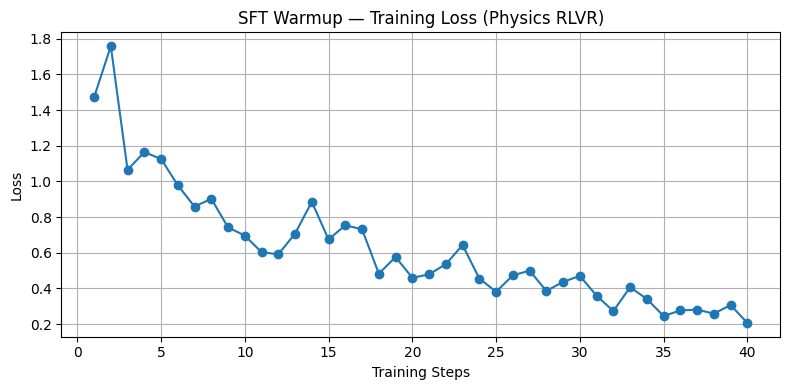

Final loss: 0.2065


In [22]:
# Plot training loss
logs   = trainer.state.log_history
steps  = [x["step"] for x in logs if "loss" in x]
losses = [x["loss"]  for x in logs if "loss" in x]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker="o", linewidth=1.5)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("SFT Warmup — Training Loss (Physics RLVR)")
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Final loss: {losses[-1]:.4f}")

## Step 9: Sanity Check

Run the trained model on 3 physics MCQ examples. We expect:
- `<START_WORKING_OUT>` and `</END_WORKING_OUT>` tags present
- `<SOLUTION>` and `</SOLUTION>` tags with a single letter inside
- Coherent step-by-step reasoning in the working-out section

Accuracy is not the goal here — format compliance is what SFT teaches.

In [23]:
FastLanguageModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): Embedding(151936, 2560, padding_idx=151654)
        (layers): ModuleList(
          (0-35): 36 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2560, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2560, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear

In [24]:
test_cases = [
    {
        "question": "A car accelerates uniformly from rest and reaches 30 m/s in 10 seconds. What is its acceleration?",
        "options": ["1 m/s²", "2 m/s²", "3 m/s²", "4 m/s²", "5 m/s²"],
    },
    {
        "question": "Colors observed in a soap bubble result from light:",
        "options": ["dispersion", "deflection", "refraction", "reflection", "interference",
                    "polarization", "absorption", "diffraction", "transmission", "scattering"],
    },
    {
        "question": "An object of mass 2 kg is moving at 4 m/s. What is its kinetic energy?",
        "options": ["4 J", "8 J", "16 J", "32 J", "64 J"],
    },
]

In [25]:
for i, tc in enumerate(test_cases):
    option_str   = "\n".join(f"{chr(65+j)}. {opt}" for j, opt in enumerate(tc["options"]))
    user_content = f"{tc['question']}\n\nOptions:\n{option_str}"

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    inputs    = {k: v.to("cuda") for k, v in inputs.items()}
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens = 512,
            temperature    = 0.0,
            do_sample      = False,
        )

    generated_tokens = output[0][input_len:]
    decoded = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    print(f"TEST CASE {i+1}: {tc['question']}")
    print("-" * 60)
    print(decoded)
    print("\n" + "=" * 60 + "\n")

TEST CASE 1: A car accelerates uniformly from rest and reaches 30 m/s in 10 seconds. What is its acceleration?
------------------------------------------------------------
<START_WORKING_OUT>
A: Let's think step by step. We refer to Wikipedia articles on classical mechanics for help. The acceleration is equal to the change in velocity divided by the change in time. The change in velocity is 30 m/s, and the change in time is 10 s, so the acceleration is 3 m/s². The answer is (C).
</END_WORKING_OUT>
<SOLUTION>
C
</SOLUTION>


TEST CASE 2: Colors observed in a soap bubble result from light:
------------------------------------------------------------
<START_WORKING_OUT>
A: Let's think step by step. We refer to Wikipedia articles on optics for help. When light waves reflect off the inner surfaces of a soap bubble, they interfere constructively or destructively with each other, depending on the difference in path length between the two reflected waves. This interference creates the colorful

## Step 10: Save Model

Two saves, two purposes:

- **Merged 16-bit** (`qwen3-4b-physics-sft/`): LoRA adapters baked into the base weights. Required for vLLM in Notebook 03 (evaluation) and usable as a standalone model.
- **LoRA adapters only** (`qwen3-4b-physics-sft-lora/`): Lightweight PEFT checkpoint (~250MB vs ~8GB). Notebook 02 (GRPO) loads this to continue training from the SFT-initialized adapter without re-merging.

In [26]:
os.makedirs(MODEL_OUT, exist_ok=True)

# Merge LoRA adapters into base weights and save as full 16-bit model
model.save_pretrained_merged(MODEL_OUT, tokenizer, save_method="merged_16bit")

print(f"SFT model saved to: {MODEL_OUT}")
print("Files saved:", os.listdir(MODEL_OUT))

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...


Unsloth: Copying 2 files from cache to `physics_rlvr/models/qwen3-4b-physics-sft`: 100%|██████████| 2/2 [00:23<00:00, 11.86s/it]


Successfully copied all 2 files from cache to `physics_rlvr/models/qwen3-4b-physics-sft`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:50<00:00, 25.07s/it]


Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/grpo-verified-reasoner/physics_rlvr/models/qwen3-4b-physics-sft`
SFT model saved to: physics_rlvr/models/qwen3-4b-physics-sft
Files saved: ['chat_template.jinja', 'tokenizer_config.json', 'special_tokens_map.json', 'added_tokens.json', 'vocab.json', 'merges.txt', 'tokenizer.json', 'config.json', '.cache', 'model.safetensors.index.json', 'model-00001-of-00002.safetensors', 'model-00002-of-00002.safetensors']


In [27]:
# Also save SFT LoRA adapters (PEFT) so GRPO can continue training the same adapter
SFT_LORA_OUT = "physics_rlvr/models/qwen3-4b-physics-sft-lora"
os.makedirs(SFT_LORA_OUT, exist_ok=True)

model.save_pretrained(SFT_LORA_OUT)   # adapter-only + PEFT config
tokenizer.save_pretrained(SFT_LORA_OUT)

print(f"SFT LoRA adapter saved to: {SFT_LORA_OUT}")
print("Files saved:", os.listdir(SFT_LORA_OUT))

SFT LoRA adapter saved to: physics_rlvr/models/qwen3-4b-physics-sft-lora
Files saved: ['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'chat_template.jinja', 'tokenizer_config.json', 'special_tokens_map.json', 'added_tokens.json', 'vocab.json', 'merges.txt', 'tokenizer.json']
